[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/07_industry_applications/24_fraud_anomaly_detection.ipynb)

# 📓 Notebook 24 — Fraud & Anomaly Detection

Fraud is the application where everything you learned about classification gets stress-tested: positives are **0.5 %** of the data, the two error types have **wildly asymmetric costs**, the adversary **adapts** to your model, and the deliverable is not a metric — it's a **review queue** that a small team of human analysts can actually work through.

> 🧠 **Mental model.** You are not building a classifier; you are building a *ranking* that decides how a fixed amount of human attention (≈ 50 case reviews per day) is spent. Every design choice follows from that.

## 🎯 Learning objectives

By the end you can:

1. Explain why **accuracy is meaningless** at 0.5 % prevalence and what to report instead (PR-AUC, precision@k, recall@k).
2. Train a cost-aware **supervised** detector with `class_weight` and pick the operating point from **analyst capacity**, not from a metric.
3. Use **Isolation Forest** for the unlabeled cold-start case and explain how it isolates anomalies.
4. Convert alerts into euros with an **expected-loss-prevented** calculation.
5. Recognize **concept drift** and explain the rules + model + feedback-loop architecture real fraud teams run.

## ✅ Prerequisites

Notebooks 1–13 and 17–19 (especially NB 18 — precision/recall and cost-based thresholds, NB 19 — pipelines). Data is generated inline; runs offline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(42)
pd.set_option("display.width", 110)
print("Setup OK")


Setup OK


## 1. The data: 90 days of payments

A payments dataset, one row per transaction. Fraud here follows three planted patterns — stolen-card *night spending*, *new-device* takeovers with high amounts, and rapid *geo-velocity* (card used in two distant cities within hours). Real fraud is messier, but these are the canonical shapes.

In [2]:
# 1a. Draw the raw transaction features (no fraud labels yet)
n = 30_000
day        = rng.integers(0, 90, n)                       # day 0..89
hour       = rng.integers(0, 24, n)
amount     = np.round(rng.lognormal(mean=3.4, sigma=0.9, size=n), 2)   # median ~30 EUR
new_device = rng.binomial(1, 0.06, n)
geo_kmh    = np.abs(rng.normal(8, 25, n))                 # implied travel speed since last txn
mcc_risk   = rng.choice([0.2, 0.5, 0.9], n, p=[0.7, 0.25, 0.05])      # merchant-category risk score
print(f"Drew {n:,} raw transactions — features: day, hour, amount, new_device, geo_kmh, mcc_risk")

Drew 30,000 raw transactions — features: day, hour, amount, new_device, geo_kmh, mcc_risk


In [3]:
# 1b. Plant the three canonical fraud patterns, then OR them into one label
fraud = np.zeros(n, dtype=int)
night_theft  = (hour <= 4) & (amount > 80) & (rng.random(n) < 0.18)
takeover     = (new_device == 1) & (amount > 150) & (rng.random(n) < 0.30)
impossible   = (geo_kmh > 120) & (rng.random(n) < 0.25)
fraud[night_theft | takeover | impossible] = 1
print(f"Planted fraud — night_theft: {night_theft.sum()}, takeover: {takeover.sum()}, "
      f"geo-velocity: {impossible.sum()} (patterns may overlap)")

Planted fraud — night_theft: 140, takeover: 17, geo-velocity: 0 (patterns may overlap)


In [4]:
# 1c. Assemble the tidy DataFrame and sanity-check the prevalence
tx = pd.DataFrame({"day": day, "hour": hour, "amount": amount, "new_device": new_device,
                   "geo_kmh": geo_kmh.round(1), "mcc_risk": mcc_risk, "fraud": fraud})
print(tx.head())
print(f"\nFraud rate: {tx['fraud'].mean():.2%}   ({tx['fraud'].sum()} fraudulent of {n:,})")
print(f"Median fraud amount: {tx.loc[tx.fraud==1,'amount'].median():.0f} EUR vs honest {tx.loc[tx.fraud==0,'amount'].median():.0f} EUR")

   day  hour  amount  new_device  geo_kmh  mcc_risk  fraud
0    8     5    5.43           0     13.7       0.5      0
1   69     8   14.00           0      1.8       0.2      0
2   58    20   12.25           0     10.5       0.5      0
3   39     2   16.39           0     14.4       0.2      0
4   38     2   39.25           0     18.4       0.2      0

Fraud rate: 0.52%   (157 fraudulent of 30,000)
Median fraud amount: 119 EUR vs honest 29 EUR


### 👀 First, look at the data

Two facts drive every modelling choice that follows: fraud is **vanishingly rare**, and when it strikes it tends to be **larger** than honest spending. Both are worth *seeing*, not just reading.

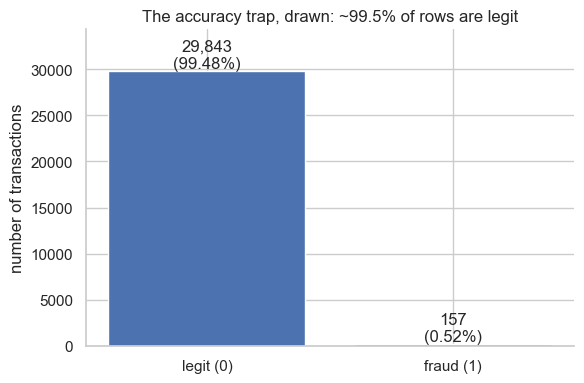

In [5]:
# The imbalance, drawn — this is the whole reason accuracy will betray us
counts = tx["fraud"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["legit (0)", "fraud (1)"], counts.values, color=["#4C72B0", "#C44E52"])
for bar, c in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, c, f"{c:,}\n({c/len(tx):.2%})",
            ha="center", va="bottom")
ax.set(ylabel="number of transactions",
       title="The accuracy trap, drawn: ~99.5% of rows are legit")
ax.margins(y=0.15)
sns.despine(); plt.tight_layout(); plt.show()

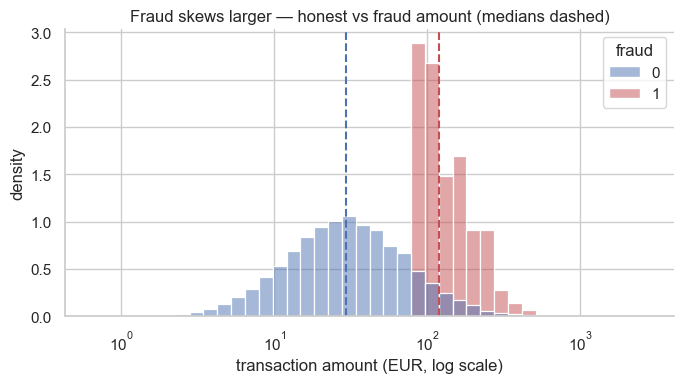

In [6]:
# Where the signal lives — fraud amounts sit to the RIGHT of honest ones (note the overlap)
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=tx, x="amount", hue="fraud", bins=40, stat="density",
             common_norm=False, log_scale=True,
             palette={0: "#4C72B0", 1: "#C44E52"}, ax=ax)
for cls, color in [(0, "#4C72B0"), (1, "#C44E52")]:
    ax.axvline(tx.loc[tx.fraud == cls, "amount"].median(), color=color, ls="--", lw=1.5)
ax.set(xlabel="transaction amount (EUR, log scale)", ylabel="density",
       title="Fraud skews larger — honest vs fraud amount (medians dashed)")
sns.despine(); plt.tight_layout(); plt.show()

## 2. The accuracy trap — see it once, never fall for it again

Before any real model: meet the world's laziest fraud detector.

In [7]:
always_honest = np.zeros(n, dtype=int)          # predicts 'not fraud' for every transaction
accuracy = (always_honest == tx["fraud"]).mean()
print(f"Accuracy of doing literally nothing: {accuracy:.2%}  <- and it catches 0 fraud. 🚩")


Accuracy of doing literally nothing: 99.48%  <- and it catches 0 fraud. 🚩


### 🔬 What actually happens when accuracy says 99.5%?

The lazy detector above scored brilliantly while catching **zero** fraud. To never be fooled again, you have to see *where* that number comes from. Every binary prediction lands in one of four boxes — the **confusion matrix**:

```text
                         PREDICTED
                  legit            fraud
              ┌──────────────┬──────────────┐
   ACTUAL     │      TN      │      FP      │   ← real legit transactions
   legit      │ (correctly   │ (false alarm)│
              │  ignored)    │              │
              ├──────────────┼──────────────┤
   ACTUAL     │      FN      │      TP      │   ← real fraud (the rare ones!)
   fraud      │ (MISSED      │ (caught      │
              │  fraud) 💀   │  fraud) ✅   │
              └──────────────┴──────────────┘
```

- **TP** (true positive) — fraud we flagged. The whole point.
- **FN** (false negative) — fraud we *missed*. Money out the door. 💀
- **FP** (false positive) — legit we flagged. An annoyed customer, an analyst's wasted hour.
- **TN** (true negative) — legit we correctly left alone.

Now picture **1,000 transactions: 990 legit, 10 fraud**. The "always legit" model predicts `legit` for all 1,000:

```text
                  predicted legit   predicted fraud
   actual legit         990                0          ← all 990 correct (TN)
   actual fraud          10                0          ← all 10 MISSED  (FN) 💀
```

**Accuracy** = (TP + TN) / everything = (0 + 990) / 1000 = **0.990**. Looks like an A+.

But accuracy counts the 990 boring correct *legit* calls and the 10 catastrophic *misses* on the **same scale** — and there are 99× more legit rows, so they drown out the fraud completely. The metric is measuring the wrong thing.


### Two honest metrics — precision and recall (both about the *positive* class)

The fix is to stop scoring the whole grid and zoom into the **fraud (positive) class** — the only thing you care about. Two questions, two metrics:

| | **Precision** | **Recall** |
|---|---|---|
| Question it answers | *Of everything we **flagged**, how much was really fraud?* | *Of all the **real fraud**, how much did we catch?* |
| Formula | `TP / (TP + FP)` | `TP / (TP + FN)` |
| Punished by | false **alarms** (FP) | **missed** fraud (FN) |
| "Always legit" model | `0 / 0` → undefined (flags nothing) | `0 / 10` = **0.0** 💀 |
| Business cost it tracks | wasted analyst time / annoyed customers | fraud losses that slipped through |

Notice what's special: **neither precision nor recall uses TN** — the 990 boring correct rows that inflated accuracy simply don't appear in either formula. That's *why* they survive imbalance. A model that flags nothing gets recall **0.0**, and the vanity disappears instantly.

> 🧠 **Mental model.** On rare-event problems, **accuracy is a vanity metric**. Always ask the two real questions on the positive class: *of what we flagged, how much was fraud?* (precision) and *of the fraud out there, how much did we catch?* (recall).


In [8]:
# 🧪 PROOF (offline, seeded) — accuracy LIES, recall tells the truth.
# A tiny, self-contained world: 990 legit + 10 fraud. No training, no downloads.
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

rng = np.random.default_rng(0)

# Ground truth: 1 = fraud, 0 = legit.  Fraud is rare (1%).
y_true = np.array([0] * 990 + [1] * 10)
rng.shuffle(y_true)                      # scatter the 10 fraud rows among the 990 legit
print(f"World: {(y_true == 0).sum()} legit, {(y_true == 1).sum()} fraud "
      f"({y_true.mean():.1%} prevalence)\n")

World: 990 legit, 10 fraud (1.0% prevalence)



In [9]:
# ── Detector A: the lazy 'predict everything is legit' baseline ──
y_lazy = np.zeros_like(y_true)           # all zeros = 'legit' for every transaction

acc  = accuracy_score(y_true, y_lazy)
rec  = recall_score(y_true, y_lazy, zero_division=0)     # of real fraud, how much caught?
prec = precision_score(y_true, y_lazy, zero_division=0)  # of flagged, how much was fraud?

print("Detector A — 'always legit' (catches nothing):")
print(f"   accuracy  = {acc:.3f}   <- looks like an A+  🤩")
print(f"   recall    = {rec:.3f}   <- the PUNCHLINE: caught 0 of 10 fraud  💀")
print(f"   precision = {prec:.3f}   (it flagged nothing, so 'undefined' -> 0)\n")

tn, fp, fn, tp = confusion_matrix(y_true, y_lazy, labels=[0, 1]).ravel()
print(f"   confusion matrix:  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"   -> 99.0% accuracy is built ENTIRELY from {tn} boring correct legit calls.")
print(f"   -> the {fn} missed fraud (FN) cost real money and accuracy never noticed.")

Detector A — 'always legit' (catches nothing):
   accuracy  = 0.990   <- looks like an A+  🤩
   recall    = 0.000   <- the PUNCHLINE: caught 0 of 10 fraud  💀
   precision = 0.000   (it flagged nothing, so 'undefined' -> 0)

   confusion matrix:  TN=990  FP=0  FN=10  TP=0
   -> 99.0% accuracy is built ENTIRELY from 990 boring correct legit calls.
   -> the 10 missed fraud (FN) cost real money and accuracy never noticed.


### A slightly-better detector — watch precision and recall move

Accuracy gave Detector A an A+. Recall gave it a **0.0** — the honest grade. Now build a *real* (if crude) detector: flag any transaction whose anomaly score crosses a threshold. It will catch most of the fraud, with a few false alarms. The point isn't the detector — it's that **precision and recall now carry information** at every threshold, while **accuracy is useless either way**: it sits at a flattering ~0.99 exactly where recall is worst, then collapses once you flag enough rows to catch the fraud — never once telling you how the fraud detection is actually going.


In [10]:
# 🧪 PROOF part 2 (offline, seeded) — a real detector makes precision & recall MOVE.
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             average_precision_score)

rng = np.random.default_rng(1)
y_true = np.array([0] * 990 + [1] * 10)
rng.shuffle(y_true)

# An 'anomaly score' per transaction: fraud rows score HIGHER on average,
# but the distributions overlap (real life is never cleanly separable).
scores = np.where(y_true == 1,
                  rng.normal(0.75, 0.15, size=y_true.size),   # fraud: high-ish
                  rng.normal(0.30, 0.15, size=y_true.size))   # legit: low-ish
scores = scores.clip(0, 1)
print(f"Built {scores.size} anomaly scores — fraud mean {scores[y_true==1].mean():.2f} "
      f"vs legit mean {scores[y_true==0].mean():.2f} (note the overlap)")

Built 1000 anomaly scores — fraud mean 0.68 vs legit mean 0.31 (note the overlap)


In [11]:
# Sweep the cutoff: flag everything at/above each threshold and watch the metrics move.
print("threshold | flagged | precision | recall | accuracy")
print("----------|---------|-----------|--------|---------")
for thr in (0.80, 0.60, 0.45, 0.30):
    y_pred  = (scores >= thr).astype(int)          # flag everything above the cutoff
    flagged = int(y_pred.sum())
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    a = accuracy_score(y_true, y_pred)
    print(f"   {thr:.2f}   |   {flagged:4d}  |   {p:.3f}   | {r:.3f}  |  {a:.3f}")

# PR-AUC (average precision) summarises the WHOLE precision/recall curve in one number,
# without you having to pick a threshold. It rewards ranking real fraud near the top.
print(f"\nPR-AUC (average precision) = {average_precision_score(y_true, scores):.3f}")
print("\nRead the table top-to-bottom: as the threshold DROPS we flag more rows,")
print("so RECALL rises (we miss less fraud) but PRECISION falls (more false alarms).")
print("That tug-of-war is the precision/recall TRADE-OFF. Accuracy is no help either way:")
print("flattering (~0.99) at the top where recall is worst, then collapsing as false alarms")
print("pile up -- it never once reflects how fraud detection is actually going.")

threshold | flagged | precision | recall | accuracy
----------|---------|-----------|--------|---------
   0.80   |      1  |   1.000   | 0.100  |  0.991
   0.60   |     28  |   0.250   | 0.700  |  0.976
   0.45   |    178  |   0.051   | 0.900  |  0.830
   0.30   |    518  |   0.019   | 1.000  |  0.492

PR-AUC (average precision) = 0.515

Read the table top-to-bottom: as the threshold DROPS we flag more rows,
so RECALL rises (we miss less fraud) but PRECISION falls (more false alarms).
That tug-of-war is the precision/recall TRADE-OFF. Accuracy is no help either way:
flattering (~0.99) at the top where recall is worst, then collapsing as false alarms
pile up -- it never once reflects how fraud detection is actually going.


> ⚠️ **The trap, in one line.** On imbalanced data a model can be *right 99% of the time* and *useless 100% of the time*. Accuracy rewards the majority class; fraud is the minority. **Report precision and recall on the positive (fraud) class — and PR-AUC to compare detectors across all thresholds.**

> 🎯 **Which knob, which metric?** Lowering the threshold trades **precision for recall** (catch more fraud, raise more false alarms); raising it does the reverse. There's no free lunch — the *right* operating point comes from the business (how many alerts can analysts review? what does a missed fraud cost?), which is exactly what Sections 5 and the cost-matrix exercise tackle with **precision@k / recall@k**.


---

### ✋ Quick exercise (~2 min) — Precision & recall by hand

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

A new detector flags **120** transactions for review. Of those, **30** turn out to be real fraud and **90** are false alarms. There were **50** frauds in the data overall. Using only the formulas just taught, compute the detector's **precision** and **recall**.

```python
TP, FP, FN = 30, 90, 20   # caught fraud, false alarms, missed fraud
```

In [12]:
# ✍️ Your turn 👇
TP, FP, FN = 30, 90, 20   # given counts
precision = ...
recall    = ...
print(precision, recall)

Ellipsis Ellipsis


<details>
<summary>✅ <b>Solution</b></summary>

```python
precision = TP / (TP + FP)   # 30 / 120
recall    = TP / (TP + FN)   # 30 / 50
print(f"precision = {precision:.2f}   recall = {recall:.2f}")
# precision = 0.25   recall = 0.60
```

Of the 120 flagged, only 1 in 4 was real fraud (precision 0.25 — lots of false alarms), while 60% of all fraud was caught (recall 0.60). Notice neither formula uses the true negatives.
</details>

> ⚠️ **Pitfall.** At 0.5 % prevalence, accuracy ≥ 99.5 % is the *floor*, not an achievement. From here on this notebook uses: **PR-AUC** (average precision) for model comparison, and **precision@k / recall@k** for operations — because the queue size *k* is what the business actually controls. ROC-AUC stays in the report (it's scale-free) but never drives a decision: with this much imbalance it flatters everyone (NB 18 §6).

## 3. Supervised detector — when you have labeled history

Banks usually do have labels (chargebacks arrive within weeks). Train on the first 60 days, evaluate on the last 30 — **time-based split**, because tomorrow's fraud is scored by a model trained on yesterday's.

In [13]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

FEATS = ["hour", "amount", "new_device", "geo_kmh", "mcc_risk"]
train, test = tx[tx["day"] < 60], tx[tx["day"] >= 60]

clf = HistGradientBoostingClassifier(max_iter=250, class_weight={0: 1, 1: 30}, random_state=42)
clf.fit(train[FEATS], train["fraud"])
score_sup = clf.predict_proba(test[FEATS])[:, 1]

print(f"Test transactions: {len(test):,}  |  fraud among them: {test['fraud'].sum()}")
print(f"PR-AUC  (supervised): {average_precision_score(test['fraud'], score_sup):.3f}")
print(f"ROC-AUC (supervised): {roc_auc_score(test['fraud'], score_sup):.3f}   <- looks inflated, as promised")


Test transactions: 9,923  |  fraud among them: 45
PR-AUC  (supervised): 0.168
ROC-AUC (supervised): 0.924   <- looks inflated, as promised


💡 **`class_weight` is the honest version of oversampling.** Weighting the rare class ×30 tells the loss function "missing a fraud hurts 30× more than a false alarm" *without* manufacturing synthetic rows. Start with weights ≈ cost ratio, then tune by the queue metrics below.

## 4. Isolation Forest — when you have *no* labels yet

New product, new market, no chargeback history: the cold-start case. **Isolation Forest** scores how *easy* a point is to isolate with random axis-aligned splits — anomalies sit alone in feature space, so they take fewer splits to fence off.

> 🎯 **Intuition.** Imagine playing "guess who" with random questions. A typical transaction needs many questions to single out; a 3 a.m. €900 purchase on a brand-new device gets isolated in two or three. The *path length* is the score.

In [14]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=300, contamination="auto", random_state=42)
iso.fit(train[FEATS])                                   # NOTE: never sees the 'fraud' column
score_iso = -iso.score_samples(test[FEATS])             # higher = more anomalous

print(f"PR-AUC (Isolation Forest, fully unsupervised): {average_precision_score(test['fraud'], score_iso):.3f}")
print("Lower than supervised — it finds *strange*, not *fraudulent*. Strange ≠ fraud:")
weird_honest = test.loc[(score_iso > np.quantile(score_iso, 0.99)) & (test['fraud'] == 0)]
print(f"  e.g. {len(weird_honest)} of the top-1% weirdest transactions are honest (big but legitimate purchases).")


PR-AUC (Isolation Forest, fully unsupervised): 0.036
Lower than supervised — it finds *strange*, not *fraudulent*. Strange ≠ fraud:
  e.g. 94 of the top-1% weirdest transactions are honest (big but legitimate purchases).


### The precision–recall curve — the right picture for rare events

At 0.5% prevalence the ROC-AUC looked flattering; the **PR curve** is the honest view because it ignores the huge, easy true-negative mass and focuses on the positives. The dashed line is what *random* guessing scores (a flat line at the prevalence rate) — any useful detector must sit well above it.


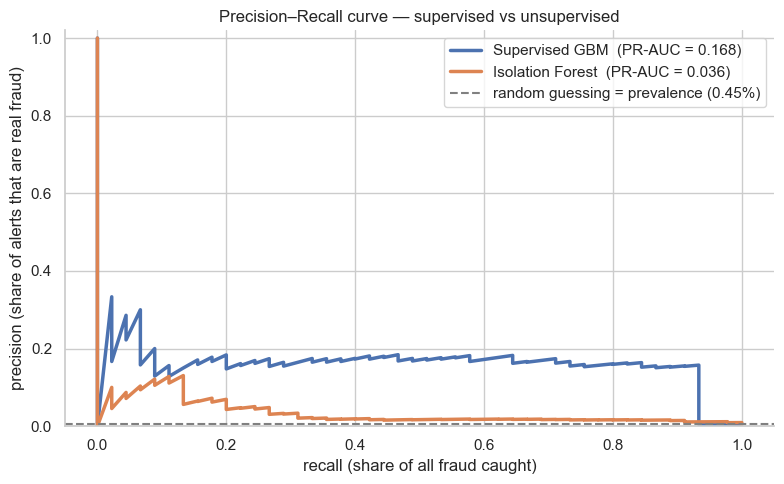

In [15]:
from sklearn.metrics import precision_recall_curve

prevalence = test["fraud"].mean()
fig, ax = plt.subplots(figsize=(8, 5))
for name, sc, color in [("Supervised GBM", score_sup, "#4C72B0"),
                        ("Isolation Forest", score_iso, "#DD8452")]:
    p, r, _ = precision_recall_curve(test["fraud"], sc)
    ap = average_precision_score(test["fraud"], sc)
    ax.plot(r, p, lw=2.5, color=color, label=f"{name}  (PR-AUC = {ap:.3f})")
ax.axhline(prevalence, ls="--", color="grey", lw=1.5,
           label=f"random guessing = prevalence ({prevalence:.2%})")
ax.set(xlabel="recall (share of all fraud caught)",
       ylabel="precision (share of alerts that are real fraud)",
       title="Precision–Recall curve — supervised vs unsupervised", ylim=(0, 1.02))
ax.legend(loc="upper right"); sns.despine(); plt.tight_layout(); plt.show()


---

### ✋ Quick exercise (~2 min) — Precision of the top 1%

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The Isolation Forest cell above profiled the *weirdest* 1% (using `np.quantile` + a boolean mask). Now do the mirror check on the **supervised** detector: of the top 1% test transactions by `score_sup`, what share are actually fraud? Reuse that same `np.quantile` + boolean-mask trick.

In [16]:
# ✍️ Your turn 👇
cutoff = np.quantile(score_sup, 0.99)   # top 1% most-risky by the supervised score
top1 = test[score_sup > cutoff]
precision_top1 = ...
print(precision_top1)

Ellipsis


<details>
<summary>✅ <b>Solution</b></summary>

```python
cutoff = np.quantile(score_sup, 0.99)
top1 = test[score_sup > cutoff]
precision_top1 = top1["fraud"].mean()
print(f"top-1% supervised precision: {precision_top1:.2%}")
```

`top1["fraud"].mean()` is the share of flagged rows that are fraud — i.e. precision at the top 1%. It runs far above the 0.5% base rate, and well above the Isolation Forest's top-1% (cell above), confirming the supervised ranking concentrates real fraud near the top.
</details>

## 5. The alert queue — where metrics meet staffing

The fraud team reviews **k = 50 alerts per day**. The only questions that matter:

- **precision@k** — of the 50 cases reviewed, how many are real? (analyst morale, trust in the system)
- **recall@k** — of all fraud, how much lands in the queue? (losses prevented)
- **€ prevented** — caught frauds × average fraud amount, minus review cost.

> 🚫 **Misconception — "Just make the alert queue bigger to catch more fraud."**
> A larger queue (bigger *k*) does raise **recall@k** — but each extra alert is more likely a false alarm, so **precision@k** falls and analyst review cost climbs. The two metrics move in *opposite* directions as *k* grows; the right queue size is set by the cost of a review vs the value of a catch, not by "more is better".

In [17]:
def queue_metrics(y_true, scores, k):
    idx = np.argsort(-scores)[:k]
    caught = int(y_true.iloc[idx].sum())
    return {"k": k, "precision@k": caught / k, "recall@k": caught / int(y_true.sum()), "caught": caught}

K = 50 * 30                                              # 50/day for the 30 test days
rows = [dict(model="supervised", **queue_metrics(test["fraud"], score_sup, K)),
        dict(model="isolation forest", **queue_metrics(test["fraud"], score_iso, K))]
qm = pd.DataFrame(rows).set_index("model")
print(qm.round(3))

                     k  precision@k  recall@k  caught
model                                                
supervised        1500        0.028     0.933      42
isolation forest  1500        0.017     0.578      26


In [18]:
REVIEW_COST, AVG_FRAUD_LOSS = 4.0, 220.0                  # EUR per review / per undetected fraud
for m in qm.index:
    caught = int(qm.loc[m, "caught"])
    net = caught * AVG_FRAUD_LOSS - K * REVIEW_COST
    print(f"{m:>17}: net value of the queue over 30 days ≈ {net:>9,.0f} EUR "
          f"({caught} caught x {AVG_FRAUD_LOSS:.0f} - {K} reviews x {REVIEW_COST:.0f})")

print("\nThe minus sign is the point, not a typo: a queue can cost more analyst time than the")
print("fraud it stops. At k=1500 the unsupervised ranking is value-DESTROYING, and even the")
print("supervised queue is far past its best size — the staffing curve below shows where the")
print(f"optimum sits. Break-even needs precision above {REVIEW_COST/AVG_FRAUD_LOSS:.2%} "
      f"(EUR{REVIEW_COST:.0f} / EUR{AVG_FRAUD_LOSS:.0f}).")

       supervised: net value of the queue over 30 days ≈     3,240 EUR (42 caught x 220 - 1500 reviews x 4)
 isolation forest: net value of the queue over 30 days ≈      -280 EUR (26 caught x 220 - 1500 reviews x 4)

The minus sign is the point, not a typo: a queue can cost more analyst time than the
fraud it stops. At k=1500 the unsupervised ranking is value-DESTROYING, and even the
supervised queue is far past its best size — the staffing curve below shows where the
optimum sits. Break-even needs precision above 1.82% (EUR4 / EUR220).


> 🎛️ **Try it live.** The cell below is interactive in Jupyter/Colab — drag the sliders to feel the trade-off. (It also runs fine without `ipywidgets`; you just get the default values as a static chart.)

In [19]:
# Interactive — needs ipywidgets (preinstalled on Colab; `pip install ipywidgets` locally)
try:
    from ipywidgets import interact, FloatSlider, IntSlider
    _HAS_WIDGETS = True
except Exception:
    _HAS_WIDGETS = False

def show_queue(daily_alerts=50):
    k = daily_alerts * 30                       # over the 30 test days
    idx = np.argsort(-score_sup)[:k]
    caught = int(test["fraud"].iloc[idx].sum())
    total = int(test["fraud"].sum())
    prec = caught / k
    rec = caught / total
    prevented = caught * AVG_FRAUD_LOSS - k * REVIEW_COST
    print(f"queue = {daily_alerts}/day  ->  {k} reviews over 30 days")
    print(f"  precision@k : {prec:6.1%}   (of reviews, share that are real fraud)")
    print(f"  recall@k    : {rec:6.1%}   (of all fraud, share caught)")
    print(f"  caught      : {caught} / {total} frauds")
    print(f"  EUR prevented: {prevented:>10,.0f}  (caught x EUR{AVG_FRAUD_LOSS:.0f} - reviews x EUR{REVIEW_COST:.0f})")

if _HAS_WIDGETS:
    interact(show_queue,
             daily_alerts=IntSlider(value=50, min=10, max=300, step=10, description="alerts/day"))
else:
    show_queue()

interactive(children=(IntSlider(value=50, description='alerts/day', max=300, min=10, step=10), Output()), _dom…

### 🔮 Predict the output

A tiny scored day: 10 transactions, exactly **2 are fraud**, sorted by descending risk score. The flags below mark fraud (`1`) in score order — one near the top, one a bit deeper.

```python
# rows sorted high->low risk; 1 = fraud. Two frauds total.
flags = [1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
total_fraud = sum(flags)
def at_k(k):
    caught = sum(flags[:k])
    return caught / k, caught / total_fraud   # precision@k, recall@k
for k in (2, 5):
    p, r = at_k(k)
    print(f"k={k}: precision={p:.2f}  recall={r:.2f}")
```

Going from k=2 to k=5, which way does **precision@k** move, and which way does **recall@k** move?

In [20]:
# Predict first, then run.
flags = [1, 0, 0, 0, 1, 0, 0, 0, 0, 0]   # sorted high->low risk; 1 = fraud
total_fraud = sum(flags)
def at_k(k):
    caught = sum(flags[:k])
    return caught / k, caught / total_fraud
for k in (2, 5):
    p, r = at_k(k)
    print(f"k={k}: precision={p:.2f}  recall={r:.2f}")

k=2: precision=0.50  recall=0.50
k=5: precision=0.40  recall=1.00


<details>
<summary>💡 <b>Answer</b></summary>

**They move in opposite directions.** At k=2 the queue catches the top fraud only: `precision=0.50, recall=0.50`. Stretching to k=5 reaches the second, deeper fraud — `recall` rises to `1.00`, but the three extra legit rows drag `precision` down to `0.40`. Growing the queue trades precision for recall; there is no free lunch — pick *k* from the cost of a review vs the value of a catch.
</details>

### The staffing trade-off as a curve (no widget needed)

The slider above is fun live, but the decision is clearer as a static chart: sweep the **daily alert budget** and plot precision@k, recall@k, and the **EUR prevented** it implies. The review team picks a column on this chart — the point where catching one more fraud stops being worth the review cost.

One thing to get right before plotting: **the sweep has to stay in the range where the queue is still hungry.** There are only 45 frauds in the 30-day test window, so a 50/day queue (k = 1500) is ~33× larger than the thing it is hunting — up there the model has already found everything it can find, recall@k is pinned flat, and the trade-off the chart is supposed to show simply isn't happening. So sweep 1–60 alerts/day instead of 10–300, and let the chart tell you where the peak really is.


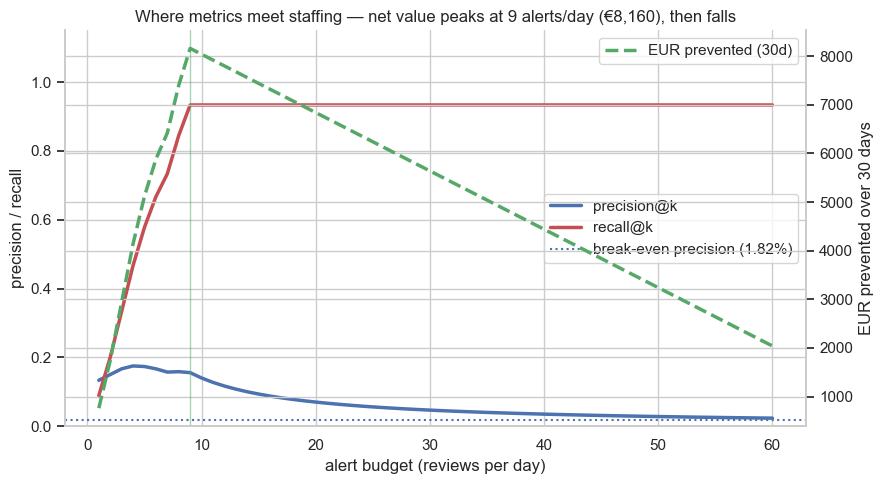

peak: 9 alerts/day -> precision@k 15.6%, recall@k 0.93, €8,160 prevented
past it, recall@k is flat at 0.93 all the way to 60/day while net value falls to €2,040 — every extra review is pure cost.
today's 50/day queue sits at €3,240 (the number printed a few cells up).


In [21]:
daily = np.arange(1, 61)                  # 1..60 reviews/day — below the saturation point
total = int(test["fraud"].sum())
precs, recs, prevented = [], [], []
for d in daily:
    k = d * 30
    idx = np.argsort(-score_sup)[:k]
    caught = int(test["fraud"].iloc[idx].sum())
    precs.append(caught / k)
    recs.append(caught / total)
    prevented.append(caught * AVG_FRAUD_LOSS - k * REVIEW_COST)

best = int(np.argmax(prevented))
interior = 0 < best < len(daily) - 1                      # a real peak, not just a grid edge
breakeven = REVIEW_COST / AVG_FRAUD_LOSS                  # a review pays for itself above this

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(daily, precs, color="#4C72B0", lw=2.5, label="precision@k")
ax1.plot(daily, recs,  color="#C44E52", lw=2.5, label="recall@k")
ax1.axhline(breakeven, color="#4C72B0", ls=":", lw=1.5,
            label=f"break-even precision ({breakeven:.2%})")
ax1.set(xlabel="alert budget (reviews per day)", ylabel="precision / recall", ylim=(0, 1.15))
ax2 = ax1.twinx()
ax2.plot(daily, prevented, color="#55A868", lw=2.5, ls="--", label="EUR prevented (30d)")
ax2.axvline(daily[best], color="#55A868", lw=1, alpha=0.5)
ax2.set_ylabel("EUR prevented over 30 days")
ax1.legend(loc="center right"); ax2.legend(loc="upper right")
if interior:
    ax1.set_title(f"Where metrics meet staffing — net value peaks at {daily[best]} alerts/day "
                  f"(€{prevented[best]:,.0f}), then falls")
else:
    ax1.set_title(f"Where metrics meet staffing — no interior optimum on this grid; best is the "
                  f"edge at {daily[best]} alerts/day (€{prevented[best]:,.0f})")
sns.despine(right=False); plt.tight_layout(); plt.show()

print(f"peak: {daily[best]} alerts/day -> precision@k {precs[best]:.1%}, recall@k {recs[best]:.2f}, "
      f"€{prevented[best]:,.0f} prevented")
print(f"past it, recall@k is flat at {recs[-1]:.2f} all the way to {daily[-1]}/day while net value "
      f"falls to €{prevented[-1]:,.0f} — every extra review is pure cost.")
print(f"today's 50/day queue sits at €{prevented[49]:,.0f} (the number printed a few cells up).")


---

### ✋ Quick exercise (~2 min) — A leaner review team

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Budget cut: the team can now review only **30 alerts/day** instead of 50. Using the `queue_metrics` helper and the cost constants (`AVG_FRAUD_LOSS`, `REVIEW_COST`) just defined, compute **recall@k** and the **€ prevented** over the 30 test days for the supervised model at this smaller queue. Did net € prevented go up or down versus the 50/day queue?

In [22]:
# ✍️ Your turn 👇
k_small = 30 * 30                       # 30 reviews/day over the 30 test days
m = queue_metrics(test["fraud"], score_sup, k_small)
prevented = ...                         # caught × AVG_FRAUD_LOSS − reviews × REVIEW_COST
print(m, prevented)

{'k': 900, 'precision@k': 0.04666666666666667, 'recall@k': 0.9333333333333333, 'caught': 42} Ellipsis


<details>
<summary>✅ <b>Solution</b></summary>

```python
k_small = 30 * 30
m = queue_metrics(test["fraud"], score_sup, k_small)
prevented = m["caught"] * AVG_FRAUD_LOSS - k_small * REVIEW_COST
print(f"recall@{k_small} = {m['recall@k']:.2f}   €prevented = {prevented:,.0f}")
```

Net € goes **up**: €5,640 at 30/day versus €3,240 at 50/day. The smaller queue lifts precision@k (4.7 % vs 2.8 %) and — because 900 alerts already hold every fraud this model can surface — costs **no recall at all** (0.93 either way). The 50/day queue was paying €2,400 of review time for zero extra catches.

That is *not* the general rule: normally a smaller queue trades recall away, and past some point the lost catches outweigh the saved reviews. It looks free here only because both queue sizes sit far above the ~270-alert saturation point from the staffing curve above. Shrink to 5/day and the trade-off is real again.
</details>

💡 **The threshold is the staffing level.** Nobody tunes a probability cutoff in fraud ops; they fill the queue to capacity, top-scores first. Want a different operating point? Hire (or automate) — that's a budget conversation, and now you have the table for it.

## 6. What production fraud systems add (the honest section)

1. **Rules + model, not rules vs model.** Hard rules catch the known patterns instantly (`geo_kmh > 900 → block`) and stay explainable to regulators; the model ranks everything the rules don't catch.
2. **Feedback loop.** Every analyst decision becomes tomorrow's label. Every *blocked* transaction becomes a missing label (you never learn if it was really fraud) — this *selective labels* problem biases naive retraining.
3. **Drift.** Fraudsters probe and adapt; monitoring PR-AUC weekly per segment is not optional (NB 32's observability mindset, applied to a model instead of an LLM).
4. **Latency.** Card authorization gives you ~100 ms. Feature stores and model simplicity matter more than the last 0.01 PR-AUC.

---


## 🧠 The story in one screen

Step back to the deliverable we promised on cell one: not a metric, but a **review queue** a small team can actually work — *which ~50 transactions deserve a human's eyes today?*

1. **The data** was 0.5 % fraud — so the first thing we did was *unlearn accuracy*. A model right 99.5 % of the time caught zero fraud; **accuracy is a vanity metric** on rare events.
2. **Precision and recall** replaced it, because they ignore the boring true-negative mass and ask the only two questions that matter: *of what we flagged, how much was fraud?* and *of the fraud out there, how much did we catch?*
3. **Two detectors** covered the two worlds: a cost-aware **supervised** model when chargeback labels exist, and **Isolation Forest** for the cold-start case with no labels yet.
4. The **alert queue** is where it became real: we never tuned a magic 0.5 cutoff — we filled the queue to analyst capacity, top-scores first, and read off precision@k / recall@k.
5. **Euros** closed the loop: caught frauds × average fraud amount − review cost turns the queue into prevented losses, and the staffing curve says exactly how big the team should be — including when the queue you already run is *too big* and the euros go negative.

> 🧭 **Mental model, one last time.** You were never building a classifier — you were **rationing a fixed amount of human attention**, and *the threshold is the staffing level*. Every choice (metric, detector, queue size) followed from that one fact. In NB 23 the dial was set by *money per customer*; here it's set by *analyst-hours per day*. Next door in NB 25 the question shifts from "who is risky?" to "who is similar?" — but the habit stays: start from the decision, work back to the model.


## 🧪 Practice exercises

Try each one **before** opening the solution. Starters run as-is.

### Exercise 1 — ⭐ `precision_recall_at_k`
Write `precision_recall_at_k(y_true, scores, k)` returning the tuple `(precision, recall)` at queue size `k`, then plot both as a function of k ∈ {25, 50, 100, …, 3200} (doubling) for the supervised model. Where does the precision curve start collapsing, and why must it?

In [23]:
# Starter
def precision_recall_at_k(y_true, scores, k):
    ...  # your code here

# ks = [25 * 2**i for i in range(8)]


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def precision_recall_at_k(y_true, scores, k):
    idx = np.argsort(-scores)[:k]
    caught = int(np.asarray(y_true)[idx].sum())
    return caught / k, caught / int(np.asarray(y_true).sum())

ks = [25 * 2**i for i in range(8)]
pr = [precision_recall_at_k(test["fraud"].to_numpy(), score_sup, k) for k in ks]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(ks, [p for p, _ in pr], "o-", label="precision@k")
ax.plot(ks, [r for _, r in pr], "s-", label="recall@k")
ax.set_xscale("log"); ax.set_xlabel("queue size k (log)"); ax.legend(); plt.tight_layout(); plt.show()
print(f"Total fraud in test = {int(test['fraud'].sum())}; once k exceeds it, precision MUST fall ~ frauds/k.")
```

**Why this works:** precision@k has a hard ceiling — there are only ~`test.fraud.sum()` frauds to find, so beyond that k every extra alert is necessarily a false positive and precision decays like frauds/k. Plotting both curves on a log-x axis is the standard way fraud teams pick a defensible queue size.
</details>

### Exercise 2 — ⭐⭐ Where do the two detectors disagree?
Take the top-1 % of test transactions by each score. How many transactions are in *both* top lists? Profile the ones only Isolation Forest flags (mean amount, hour, `new_device` rate) against the ones only the supervised model flags. What kind of fraud would each miss alone?

In [24]:
# Starter
top_n = int(0.01 * len(test))
# sup_top = ...; iso_top = ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
top_n = int(0.01 * len(test))
sup_top = set(np.argsort(-score_sup)[:top_n])
iso_top = set(np.argsort(-score_iso)[:top_n])
both, only_sup, only_iso = sup_top & iso_top, sup_top - iso_top, iso_top - sup_top
print(f"overlap {len(both)} | only supervised {len(only_sup)} | only isolation {len(only_iso)}")

prof = pd.DataFrame({
    "only_supervised": test.iloc[list(only_sup)][["amount", "hour", "new_device", "fraud"]].mean(),
    "only_isolation":  test.iloc[list(only_iso)][["amount", "hour", "new_device", "fraud"]].mean(),
}).round(2)
print(prof)
```

**Why this works:** the supervised list concentrates on the *labeled* patterns (its `fraud` hit-rate is much higher); the isolation list contains extreme-but-honest outliers plus genuinely novel shapes the labels don't cover yet. That asymmetry is the argument for running both: supervised for known fraud, unsupervised as the tripwire for *new* fraud — exactly the §6 hybrid.
</details>

### Exercise 3 — ⭐⭐ Debug me 🐞: The 99.6 %-accurate disaster
A consultant delivers the model below with the subject line *"99.6 % accurate fraud AI"*. The cell runs without errors — find **both** problems (one metric, one split) and write the honest evaluation.

In [25]:
# The consultant's deliverable — runs fine. What TWO things are wrong with the evaluation?
from sklearn.model_selection import train_test_split as tts_random
from sklearn.metrics import accuracy_score

Xr_tr, Xr_te, yr_tr, yr_te = tts_random(tx[FEATS], tx["fraud"], test_size=0.3, random_state=0)
consultant = HistGradientBoostingClassifier(max_iter=100, random_state=0).fit(Xr_tr, yr_tr)
pred_labels = consultant.predict(Xr_te)
print(f"Accuracy: {accuracy_score(yr_te, pred_labels):.3%}  🚀 (says the invoice)")


Accuracy: 99.222%  🚀 (says the invoice)


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
# Problem 1 — the metric: at 0.5% prevalence, predicting mostly 'honest' yields ~99.5%
#             accuracy while catching almost nothing. Report PR-AUC / queue metrics instead.
# Problem 2 — the split: random splitting mixes future and past. Fraud patterns drift,
#             so the only honest split is temporal: train on days <60, test on days >=60.
honest = HistGradientBoostingClassifier(max_iter=100, class_weight={0: 1, 1: 30},
                                        random_state=0).fit(train[FEATS], train["fraud"])
s = honest.predict_proba(test[FEATS])[:, 1]
print(f"PR-AUC (temporal split): {average_precision_score(test['fraud'], s):.3f}")
idx = np.argsort(-s)[:1500]
print(f"precision@1500: {test['fraud'].iloc[idx].mean():.2f} | recall@1500: "
      f"{test['fraud'].iloc[idx].sum() / test['fraud'].sum():.2f}")
```

**Why this works:** the consultant's number is the §2 accuracy trap wearing a suit, measured on a split that lets the model peek at the future's distribution. The honest version changes *both* axes: a prevalence-proof metric and a time-respecting split. (Both lessons transfer verbatim to churn, maintenance, and any other "predict the future" problem.)
</details>

### Exercise 4 — ⭐⭐ The cost matrix decides the weight
Missing a fraud costs €220; a false alarm costs €4 of review time. For `class_weight={0:1, 1:w}` with w ∈ {1, 10, 30, 100}, retrain on the training window and report total expected cost on the test window at queue size k = 1500. Which w wins, and why is the answer *not* simply 220/4?

In [26]:
# Starter
# for w in (1, 10, 30, 100): ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
results = []
for w in (1, 10, 30, 100):
    m = HistGradientBoostingClassifier(max_iter=150, class_weight={0: 1, 1: w},
                                       random_state=42).fit(train[FEATS], train["fraud"])
    s = m.predict_proba(test[FEATS])[:, 1]
    idx = np.argsort(-s)[:1500]
    caught = int(test["fraud"].iloc[idx].sum())
    missed = int(test["fraud"].sum()) - caught
    cost = missed * 220 + 1500 * 4
    results.append({"w": w, "caught@1500": caught, "missed": missed, "total_cost_eur": cost})
print(pd.DataFrame(results).to_string(index=False))
```

**Why this works:** with a *fixed* queue size, the weight only matters through the **ranking** it produces, not through the decision threshold — so the theoretical 55:1 cost ratio is a starting point, not the answer. In this run the unweighted model (w=1) and w=10 tie for the win, while the heavier weights (w=30, w=100) actually rank *worse*, shuffling a couple of real frauds out of the top-k: big weights distort the probability surface without adding any information. The takeaway isn't that any particular w is magic — it's that the winner came from running the experiment, not from the cost matrix. Measure, don't derive.
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ Drift: when the fraudsters read your model
Simulate adaptation: in a copy of the test window, give *new* fraud the opposite profile (daytime hours 10–16, amounts 40–90 — under the old pattern's radar). Score it with the *old* supervised model and with Isolation Forest. Which degrades more, and what does that say about the §6 hybrid?

In [27]:
# Starter — build ~150 drifted fraud rows, append to honest test rows, rescore both models.


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
d_rng = np.random.default_rng(5)
n_new = 150
drifted = pd.DataFrame({
    "day": d_rng.integers(60, 90, n_new),
    "hour": d_rng.integers(10, 17, n_new),
    "amount": np.round(d_rng.uniform(40, 90, n_new), 2),
    "new_device": d_rng.binomial(1, 0.5, n_new),          # device takeovers persist
    "geo_kmh": np.abs(d_rng.normal(8, 10, n_new)).round(1),
    "mcc_risk": d_rng.choice([0.2, 0.5, 0.9], n_new, p=[0.4, 0.4, 0.2]),
    "fraud": 1})
honest_test = test[test["fraud"] == 0]
drift_world = pd.concat([honest_test, drifted], ignore_index=True)

s_sup = clf.predict_proba(drift_world[FEATS])[:, 1]
s_iso = -iso.score_samples(drift_world[FEATS])
for name, s in [("supervised", s_sup), ("isolation", s_iso)]:
    print(f"{name:>11}: PR-AUC on drifted fraud = {average_precision_score(drift_world['fraud'], s):.3f}")
```

**Why this works:** the supervised model collapses — its discriminative signal *was* the old pattern. Isolation Forest degrades more gracefully on whatever stays unusual (the new-device share) but also misses fraud designed to look typical. Moral: no static detector survives an adapting adversary; the defensible architecture is rules + supervised + anomaly tripwire + **retraining cadence**, monitored like NB 32 monitors LLMs.
</details>

### Stretch exercise B — ⭐⭐ Per-segment queues
A single global queue lets high-volume segments crowd out the rest. Split the queue by `mcc_risk` segment (k proportional to segment volume) and compare overall recall@k against the global queue at a **tight** queue of `k = 150` (5 alerts/day).

Why 150 and not the notebook's 1500? Because there are only 45 frauds in the test window: by k ≈ 270 the supervised ranking has already surfaced all 42 it can find, so *every* queue design — global, quota, ensemble — returns the same recall 0.93 and the comparison is dead on arrival. Any queue-design experiment has to run below saturation. When does segmentation help, and what's the governance argument for it even when it doesn't?

In [28]:
# Starter
# for seg, grp in test.groupby("mcc_risk"): ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
K_total = 150                    # 5 alerts/day — below the ~270 where the queue saturates
test_s = test.copy(); test_s["score"] = score_sup
caught_seg = 0
for seg, grp in test_s.groupby("mcc_risk"):
    k_seg = int(round(K_total * len(grp) / len(test_s)))
    hit = int(grp.nlargest(k_seg, "score")["fraud"].sum())
    caught_seg += hit
    print(f"  segment mcc_risk={seg}: {k_seg:>3} slots -> {hit} fraud (segment holds "
          f"{int(grp['fraud'].sum())})")
caught_glob = int(test_s.nlargest(K_total, "score")["fraud"].sum())
total = int(test_s["fraud"].sum())
print(f"global queue: recall {caught_glob/total:.2f} ({caught_glob}/{total}) | "
      f"per-segment: recall {caught_seg/total:.2f} ({caught_seg}/{total})")
```

**Why this works:** the global queue is recall-optimal *if* scores are comparable across segments — which they often aren't (different base rates make the same score mean different risks). At k = 150 the global queue catches 26 of 45 frauds (recall 0.58) and the proportional quotas catch 24 (recall 0.53): the quota reserves 7 slots for the thin high-risk segment, and here those slots come back empty, so the coverage guarantee costs two catches.

Two caveats worth stating out loud. The *sign* of that gap is not universal — at some queue sizes the quota actually wins, because forcing coverage of a thin segment surfaces a fraud the global ranking had buried; don't over-read one decimal. And run the same comparison at k = 1500 and both schemes return recall 0.93, because the queue is by then far larger than the 45 frauds it is hunting. Which is the real lesson: pick per-segment quotas for the **fairness/governance** property — "we review every merchant category daily" survives an audit; "the model decided" does not (NB 52's RACI applies to models, too) — not for a recall decimal that flips with k.
</details>

### Stretch exercise C — ⭐⭐⭐ Rank-ensemble the two detectors
Combine supervised and isolation scores into one queue by *average rank* (not by averaging raw scores — they live on different scales). Does the ensemble beat the better single model at k = 150 (same below-saturation queue as Stretch B)? Try weights 0.7/0.3 as well.

In [29]:
# Starter
# from scipy.stats import rankdata


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
from scipy.stats import rankdata

K_ens = 150                            # below saturation, so the queues can actually differ
r_sup = rankdata(score_sup)            # higher score -> higher rank number
r_iso = rankdata(score_iso)
total = int(test["fraud"].sum())
for w in (0.5, 0.7):
    combo = w * r_sup + (1 - w) * r_iso
    idx = np.argsort(-combo)[:K_ens]
    print(f"w_sup={w}: precision@{K_ens} = {test['fraud'].iloc[idx].mean():.3f}, "
          f"recall@{K_ens} = {test['fraud'].iloc[idx].sum()/total:.2f}")
idx_s = np.argsort(-score_sup)[:K_ens]
print(f"supervised alone: precision@{K_ens} = {test['fraud'].iloc[idx_s].mean():.3f}, "
      f"recall@{K_ens} = {test['fraud'].iloc[idx_s].sum()/total:.2f}")
```

**Why this works:** ranks are scale-free, so averaging them is the cheapest sane way to fuse heterogeneous detectors (the same trick NB 29 hinted at for hybrid keyword + dense retrieval). At k = 150 the answer is unambiguous and *negative*: supervised alone catches 26 frauds (recall 0.58), the 0.7/0.3 blend 16 (0.36), the 50/50 blend 12 (0.27). Mixing a much weaker detector into the ranking (Isolation Forest PR-AUC 0.036 vs the supervised model's 0.168) drags the queue **down** — rank fusion pays only when the components are comparably strong, or when they see genuinely different fraud.

Note what the notebook's default k = 1500 would have told you instead: all three tie at recall 0.93, because that queue is 33× larger than the 45 frauds in the window. A tie is not evidence of equivalence — it's evidence your evaluation point is saturated. The ensemble's real value shows up under Stretch A's drift, where the isolation component keeps novel fraud from sailing through unranked. Evaluate ensembles under the conditions they're meant to survive.
</details>

### Stretch exercise D — ⭐⭐⭐ The selective-labels problem
§6 said: blocked transactions never get a true label. Simulate it — retrain the supervised model using *only* transactions your first model's top-1500 didn't catch (pretend the caught ones were blocked, so their labels vanish). What happens to next month's PR-AUC, and what's the standard mitigation?

In [30]:
# Starter — drop the top-1500 alerts from the training pool of a 'second generation' model.


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
# gen-1 is the model we already have (clf, trained on days <60 with every label intact).
blocked  = test.index[np.argsort(-score_sup)[:1500]]   # top-1500 alerts: blocked, labels vanish
labelled = test.drop(index=blocked)                    # the ONLY rows gen-2 gets to learn from
print(f"gen-2 sees {len(labelled):,} rows but only {int(labelled['fraud'].sum())} of the "
      f"{int(test['fraud'].sum())} frauds — the rest were blocked and never labelled.")

gen2 = HistGradientBoostingClassifier(max_iter=150, class_weight={0: 1, 1: 30},
                                      random_state=1).fit(labelled[FEATS], labelled["fraud"])

# Control: censor the SAME number of rows at RANDOM. Same training-set size, no selection
# bias — so it separates "less data" from "systematically the wrong data".
c_rng = np.random.default_rng(0)
ctrl_pool = test.drop(index=test.index[c_rng.permutation(len(test))[:1500]])
ctrl = HistGradientBoostingClassifier(max_iter=150, class_weight={0: 1, 1: 30},
                                      random_state=1).fit(ctrl_pool[FEATS], ctrl_pool["fraud"])

# 'Next month' = a genuinely FRESH draw from the same generator. Scoring on `train` or `test`
# would measure memorisation: every model here was fitted on those rows.
f_rng = np.random.default_rng(999)
m = 10_000
f_hour   = f_rng.integers(0, 24, m)
f_amount = np.round(f_rng.lognormal(3.4, 0.9, m), 2)
f_new    = f_rng.binomial(1, 0.06, m)
f_geo    = np.abs(f_rng.normal(8, 25, m))
f_mcc    = f_rng.choice([0.2, 0.5, 0.9], m, p=[0.7, 0.25, 0.05])
f_fraud  = np.zeros(m, dtype=int)
f_fraud[((f_hour <= 4) & (f_amount > 80) & (f_rng.random(m) < 0.18))
        | ((f_new == 1) & (f_amount > 150) & (f_rng.random(m) < 0.30))
        | ((f_geo > 120) & (f_rng.random(m) < 0.25))] = 1
nxt = pd.DataFrame({"hour": f_hour, "amount": f_amount, "new_device": f_new,
                    "geo_kmh": f_geo.round(1), "mcc_risk": f_mcc, "fraud": f_fraud})
print(f"fresh month: {len(nxt):,} transactions, {int(nxt['fraud'].sum())} frauds\n")

for name, model in [("gen-1 (all labels)", clf),
                    ("gen-2 (labels censored by the model)", gen2),
                    ("control (same size, censored at random)", ctrl)]:
    ap = average_precision_score(nxt["fraud"], model.predict_proba(nxt[FEATS])[:, 1])
    print(f"{name:<40}: next-month PR-AUC = {ap:.3f}")
```

**Why this works:** gen-2 collapses — next-month PR-AUC **0.033 versus gen-1's 0.205**, while the random-censoring control lands at 0.204, statistically on top of gen-1. Three design choices make that number mean something, and each one is a mistake worth naming:

1. **gen-2 trains *only* on the rows the first model didn't block.** Quietly folding the original training window back in hands gen-2 every old fraud label it was supposed to lose — and then the "censored" model scores *the same as or better than* gen-1, because all you actually did was add data. The censoring has to bite.
2. **Both models are scored on a genuinely fresh month.** Evaluating on `train` or `test` measures memorisation, not generalisation: both models were fitted on those rows, and the PR-AUCs come out several times higher than anything either model would achieve in production.
3. **The control isolates the cause.** With an identical number of training rows, the only difference is *which* rows vanished. So the collapse is the selection, not the sample size.

The mechanism: the second model trains on a world where the obvious fraud was surgically removed, so it unlearns exactly the patterns the first model knew best — and the feedback loop tightens every generation. Mitigations used in practice: let a small random fraction of alerts through unblocked (exploration — literally the control group above), keep old labelled patterns in the training set with their historical labels, and weight recent labels by their sampling probability (inverse propensity).
</details>

## 🎁 Bonus mini-project — the morning alert digest

Write `daily_digest(day)` that returns a markdown report for one test day: number of alerts, top 5 by score with their features, estimated € at risk, precision so far this month, and one drift indicator (today's mean score vs the 30-day mean). This is the artifact a fraud-ops lead actually opens at 8:55. If you did NB 46, you know where it runs next (the scheduler); if you did NB 28, you know who can draft the prose summary from your numbers.

## ✅ Self-assessment checklist

- [ ] I can explain to a stakeholder why their 99.6 %-accuracy fraud model is worthless, in two sentences.
- [ ] I can choose between supervised and Isolation Forest based on label availability — and argue for both.
- [ ] I can size an alert queue from analyst capacity and report precision@k / recall@k / € prevented.
- [ ] I can name the two ways this notebook's evaluation respected time, and what breaks if you don't.
- [ ] I can describe the selective-labels feedback trap and one mitigation.

## 🚀 Next step

Continue with **Notebook 25 — Customer Segmentation & Recommenders** (`./25_segmentation_recommenders.ipynb`) — from "who is risky?" to "who is similar, and what will they want next?". Unsupervised learning finally gets its own stage.